In [18]:
from pprint import pprint

# Importing the Model

In [57]:
import torch
from transformers import (
    CLIPModel,
    CLIPProcessor  # encapsulates ImageProcessor and Tokenizer
)

In [9]:
model_id = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_id)
clip_processor = CLIPProcessor.from_pretrained(model_id)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Playground

## Sample Image

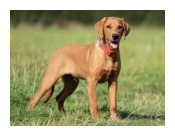

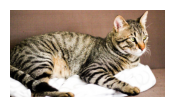

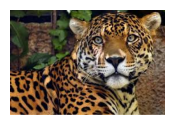

In [135]:
import requests
import io
from PIL import Image
import matplotlib.pyplot as plt

urls = [
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTdrGKdSjRcEr4t-18YFnt9qGZ7wsTm0c1mfQ&s',
    'https://www.cdc.gov/flu-in-animals/media/images/fluincatsothertp4.jpg',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSgAPStb2BZ80ZL72N0kIrSYQY0EslSceLZ8w&s'
]

images = []

for url in urls:
    response = requests.get(url)
    image = Image.open(io.BytesIO(response.content))

    plt.figure(figsize=(2, 4))
    plt.axis('off')
    plt.imshow(image)
    plt.show()
    
    images.append(image)

## Processor

In [118]:
image_features = clip_processor(images=image, return_tensors='pt')
pprint(image_features)

{'pixel_values': tensor([[[[-0.8726, -0.9602, -1.0623,  ..., -1.7777, -1.7485, -1.6901],
          [-0.9310, -0.9748, -1.0623,  ..., -1.7631, -1.7339, -1.6755],
          [-1.0185, -1.0331, -1.0623,  ..., -1.7339, -1.7047, -1.6609],
          ...,
          [ 0.8938,  0.8501,  0.6457,  ...,  0.6749,  0.3099,  0.0617],
          [ 0.8209,  0.7479,  0.7333,  ...,  0.5289,  0.3683,  0.3537],
          [ 1.2734,  1.2734,  1.1274,  ...,  0.8501,  0.8209,  0.9230]],

         [[-0.7316, -0.8216, -0.9267,  ..., -1.6921, -1.6621, -1.6170],
          [-0.7916, -0.8366, -0.9267,  ..., -1.7071, -1.6621, -1.6170],
          [-0.8816, -0.8967, -0.9267,  ..., -1.6921, -1.6771, -1.6320],
          ...,
          [ 0.2139,  0.2139,  0.0338,  ...,  0.5441,  0.1689, -0.0862],
          [ 0.1539,  0.1239,  0.1389,  ...,  0.3940,  0.2289,  0.2139],
          [ 0.6341,  0.6792,  0.5441,  ...,  0.7392,  0.6942,  0.7992]],

         [[-0.8261, -0.9114, -1.0252,  ..., -1.2811, -1.2811, -1.2527],
          [-0

In [119]:
texts = [
    'a photo of an animal',
    'a photo of a wolf',
    'a photo of a dog',
    'a photo of a cat',
]

In [120]:
text_tokens = clip_processor(text=texts, return_tensors='pt')
pprint(text_tokens)

{'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1]]),
 'input_ids': tensor([[49406,   320,  1125,   539,   550,  4668, 49407],
        [49406,   320,  1125,   539,   320,  5916, 49407],
        [49406,   320,  1125,   539,   320,  1929, 49407],
        [49406,   320,  1125,   539,   320,  2368, 49407]])}


In [122]:
inputs = clip_processor(
    text=texts,
    images=images,
    return_tensors='pt',
    padding=True
)

pprint(inputs)

{'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1]]),
 'input_ids': tensor([[49406,   320,  1125,   539,   550,  4668, 49407],
        [49406,   320,  1125,   539,   320,  5916, 49407],
        [49406,   320,  1125,   539,   320,  1929, 49407],
        [49406,   320,  1125,   539,   320,  2368, 49407]]),
 'pixel_values': tensor([[[[-1.1207, -1.1207, -1.1061,  ..., -1.1207, -1.2083, -1.1937],
          [-1.1353, -1.1353, -1.1207,  ..., -1.1061, -1.1937, -1.1791],
          [-1.1499, -1.1499, -1.1353,  ..., -1.0915, -1.1791, -1.1645],
          ...,
          [ 0.4267,  0.2077,  0.1931,  ...,  0.0909,  0.1639,  0.0909],
          [ 0.3683,  0.3245,  0.0325,  ...,  0.1055, -0.0259,  0.0033],
          [ 0.4997,  0.3245, -0.0550,  ...,  0.2515,  0.2661,  0.1201]],

         [[-0.9417, -0.9417, -0.9267,  ..., -0.8816, -0.9717, -0.9567],
          [-0.9567, -0.9567, -0.9417,  ..., -0.8666, -0.9567, -0.

In [123]:
with torch.inference_mode():
    outputs = clip_model(**inputs)

In [124]:
logits_per_image = outputs.logits_per_image
logits_per_image

tensor([[24.6782, 20.6476, 27.5335, 18.9976],
        [24.1209, 19.1873, 20.6242, 26.4175],
        [25.9572, 18.2398, 20.6533, 24.3390]])

Image 1


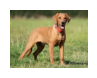

a photo of a dog.............. :  94.45%
a photo of an animal.......... :   5.43%
a photo of a wolf............. :   0.10%
a photo of a cat.............. :   0.02%

Image 2


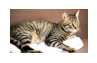

a photo of a cat.............. :  90.55%
a photo of an animal.......... :   9.11%
a photo of a dog.............. :   0.28%
a photo of a wolf............. :   0.07%

Image 3


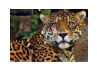

a photo of an animal.......... :  83.08%
a photo of a cat.............. :  16.47%
a photo of a dog.............. :   0.41%
a photo of a wolf............. :   0.04%



In [151]:
probs = logits_per_image.softmax(dim=1)

for i, (prob, image) in enumerate(zip(probs, images), start=1):
    print('\033[1;4m' + f'Image {i}')
    plt.figure(figsize=(1, 2))
    plt.axis('off')
    plt.imshow(image)
    plt.show()

    pairs = zip(texts, prob.tolist())
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    
    for text, p in pairs:
        prob_string = f'{(p*100):.2f}'

        print('\033[1m' if p > 0.8 else '\033[m', end='')
        print(f'{text:.<30}', ':', f'{prob_string:>6}%')

    print()

In [192]:
texts = [
    'cachorro',
    'cane',
    # 'canis familiaris',
    'chien',
    'dog',
    'hund',
    'perro'
]

inputs = clip_processor(
    images=images[0],
    text=texts,
    padding=True,
    return_tensors='pt'
)

with torch.inference_mode():
    outputs = clip_model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)[0]

pairs = zip(texts, probs)
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

pprint([f'{pair[0]} : {pair[1]*100:.2f}%' for pair in pairs])

['dog : 30.15%',
 'cachorro : 28.48%',
 'chien : 23.06%',
 'cane : 8.61%',
 'perro : 5.64%',
 'hund : 4.05%']
